# 15 · Brownian motion

Brownian motion is the continuous limit of the random walk and the building block of continuous-time
stochastic models: diffusion, stock prices, measurement noise, the Ornstein-Uhlenbeck process. This notebook
constructs it (increments, Lévy's midpoint refinement, Donsker's scaled walk), studies its strange paths
(continuous, nowhere differentiable, with quadratic variation t), uses the reflection principle for maxima,
first passages and barrier options, and fits geometric Brownian motion to six years of stock prices.

**What you will learn**
- construct Brownian paths by increments, midpoint refinement and scaled walks
- explain quadratic variation and its consequences
- use the reflection principle for maxima, first passages and barriers
- fit geometric Brownian motion to price data and test it

**Before you start:** notebooks 07 and 09; the normal distribution  ·  **Time:** about 75 min

In [1]:
try:                      # on Google Colab (or anywhere engstoch is missing): install it from GitHub
    import engstoch
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engstoch"], check=True)
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from engstoch import brownian as bm, walks as wk, datasets
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")

R = np.random.default_rng      # R(seed): a fresh, reproducible generator

## Constructions

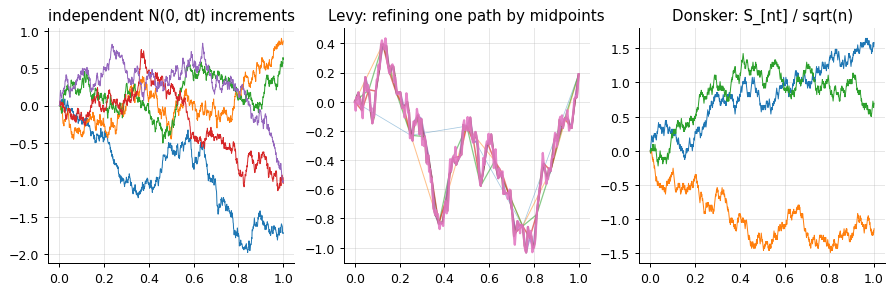

Cov(W_s, W_t) at s, t = 0.25, 0.5, 1:
 [[0.249 0.251 0.245]
 [0.251 0.504 0.5  ]
 [0.245 0.5   0.996]]


In [2]:
fig, ax = plt.subplots(1, 3, figsize=(12, 3.4))
t = bm.time_grid(1.0, 1000)
W = bm.paths(1.0, 1000, 5, R(1))
for w in W: ax[0].plot(t, w, lw=0.8)
ax[0].set_title("independent N(0, dt) increments")
coarse = bm.bridge_construction(1.0, 2, 1, R(2))
for lev in range(7):
    ax[1].plot(np.linspace(0, 1, coarse.shape[1]), coarse[0], lw=0.6 + 0.2 * lev, alpha=0.4 + 0.08 * lev)
    coarse = bm.refine(coarse, 1.0, R(3 + lev))
ax[1].set_title("Levy: refining one path by midpoints")
d = bm.donsker(1000, 3, R(4))
for w in d: ax[2].plot(np.linspace(0, 1, 1001), w, lw=0.8)
ax[2].set_title("Donsker: S_[nt] / sqrt(n)"); plt.show()
Wm = bm.paths(1.0, 512, 20_000, R(5))
print("Cov(W_s, W_t) at s, t = 0.25, 0.5, 1:\n", np.round(np.cov(Wm[:, [128, 256, 512]].T), 3))

Gaussian increments on a grid are exact at the grid points. Lévy's construction fills in midpoints from the
conditional law of a Brownian bridge, (W_a + W_b)/2 + N(0, Δt/4), so a path can be refined where needed
without changing what was already simulated - the basis of the Brownian-bridge technique in quasi-Monte Carlo
and adaptive SDE solvers. Donsker's theorem says the rescaled random walk converges in law, as a whole path,
to Brownian motion; the covariance is min(s, t).

## Rough paths: quadratic variation

In [3]:
Wf = bm.paths(1.0, 2**18, 1, R(6))[0]
rows = []
for k in (4, 6, 8, 10, 12, 14, 16, 18):
    sub = Wf[:: 2 ** (18 - k)]
    rows.append((2**k, bm.quadratic_variation(sub)[0], bm.total_variation(sub)[0], np.sqrt(2 * 2**k / np.pi)))
print(pd.DataFrame(rows, columns=["intervals", "sum of squared increments", "sum of |increments|", "sqrt(2n/pi)"]).to_string(index=False, float_format="%.3f"))

 intervals  sum of squared increments  sum of |increments|  sqrt(2n/pi)
        16                      0.733                2.760        3.192
        64                      0.854                5.586        6.383
       256                      0.942               12.229       12.766
      1024                      0.987               25.285       25.532
      4096                      1.002               50.767       51.065
     16384                      0.992              101.414      102.129
     65536                      1.001              204.278      204.258
    262144                      1.002              408.931      408.517


Refining the partition, the sum of squared increments converges to t = 1 while the sum of absolute increments
grows without bound like √n: Brownian paths have infinite length and finite quadratic variation. This is why
ordinary calculus fails for them and Itô's (dW)² = dt rule (notebook 16) is needed.

## The reflection principle: maxima and first passages

P(max_[0,1] W >= 1): grid of 2000 steps 0.3041, reflection principle 2(1 - Phi(1)) = 0.3173


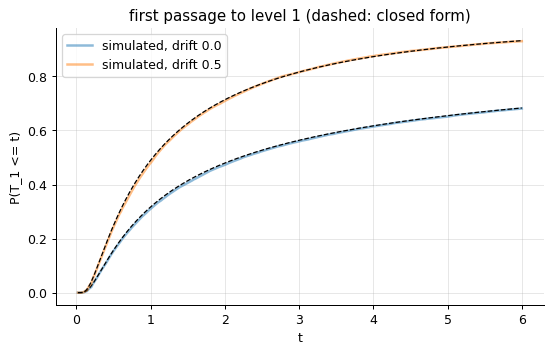

P(T_1 <= 2) with 50 steps: discrete monitoring 0.6698, with the bridge correction 0.7095, exact 0.7138


In [4]:
T, a = 1.0, 1.0
W = bm.paths(T, 2000, 20_000, R(7))
print(f"P(max_[0,1] W >= 1): grid of 2000 steps {np.mean(W.max(axis=1) >= a):.4f}, reflection principle 2(1 - Phi(1)) = {bm.max_cdf(a, T):.4f}")
tt = np.linspace(0.02, 6, 300)
for mu in (0.0, 0.5):
    fp = bm.first_passage_simulated(1.0, 6.0, 600, 20_000, R(8), drift=mu, bridge_correction=True)
    plt.plot(tt, [np.mean(fp <= x) for x in tt], lw=2, alpha=0.5, label=f"simulated, drift {mu}")
    plt.plot(tt, bm.first_passage_cdf(tt, 1.0, mu), "k--", lw=1)
plt.legend(); plt.xlabel("t"); plt.ylabel("P(T_1 <= t)"); plt.title("first passage to level 1 (dashed: closed form)"); plt.show()
fpn = bm.first_passage_simulated(1.0, 2.0, 50, 40_000, R(9), drift=0.5)
fpc = bm.first_passage_simulated(1.0, 2.0, 50, 40_000, R(9), drift=0.5, bridge_correction=True)
print(f"P(T_1 <= 2) with 50 steps: discrete monitoring {np.mean(fpn <= 2):.4f}, with the bridge correction {np.mean(fpc <= 2):.4f}, exact {bm.first_passage_cdf(2.0, 1.0, 0.5):.4f}")

Reflecting the path after its first hit of a shows P(max_{s≤t} W_s ≥ a) = 2P(W_t ≥ a): the maximum has the law
of |W_t|. With drift the first-passage time is inverse Gaussian; without drift it is finite with probability
one yet has infinite mean. Checking the level only at grid points misses crossings between them and biases
the probability low; the Brownian-bridge correction (the probability that the bridge between two grid values
crosses a is exp(−2(a − x_k)(a − x_{k+1})/(σ²Δt))) removes the bias almost completely.

## Geometric Brownian motion on real prices

whole record: volatility 0.243, drift 0.253 +- 0.100 per year


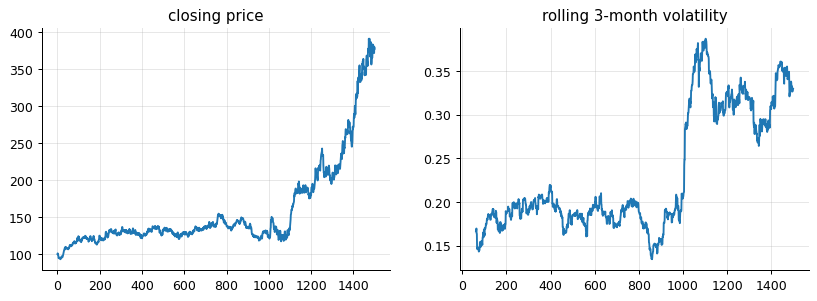

days 0-999: volatility 0.185, normality of log-returns (KS p) 0.692
days 1000-1499: volatility 0.329, normality of log-returns (KS p) 0.822
whole record pooled: excess kurtosis 1.29 (0 for one GBM) -> a mixture of two volatilities looks heavy-tailed


In [5]:
pr = pd.read_csv(datasets.path("prices.csv"), comment="#")
lr = np.diff(np.log(pr.close.to_numpy()))
mu_hat, sig_hat = lr.mean() * 252 + 0.5 * lr.var(ddof=1) * 252, lr.std(ddof=1) * np.sqrt(252)
print(f"whole record: volatility {sig_hat:.3f}, drift {mu_hat:.3f} +- {sig_hat / np.sqrt(len(lr) / 252):.3f} per year")
roll = pd.Series(lr).rolling(63).std() * np.sqrt(252)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].plot(pr.close); ax[0].set_title("closing price"); ax[1].plot(roll); ax[1].set_title("rolling 3-month volatility"); plt.show()
for name, x in (("days 0-999", lr[:1000]), ("days 1000-1499", lr[1000:])):
    print(f"{name}: volatility {x.std(ddof=1) * np.sqrt(252):.3f}, normality of log-returns (KS p) {stats.kstest((x - x.mean()) / x.std(), 'norm').pvalue:.3f}")
print(f"whole record pooled: excess kurtosis {stats.kurtosis(lr):.2f} (0 for one GBM) -> a mixture of two volatilities looks heavy-tailed")

Under GBM log-returns are i.i.d. normal, so the volatility is estimated precisely from daily data while the
drift is barely identifiable (its standard error over six years is about 10 % per year - the "mean blur" of
finance). The rolling volatility reveals a regime change after day 1000; each regime is consistent with GBM,
but the pooled returns are fat-tailed. Heavy tails in real returns are partly this: volatility that moves.

## Pricing with Brownian motion

In [6]:
S0, K, r_, sig, T = 100.0, 100.0, 0.05, 0.2, 1.0
ST = bm.gbm(S0, r_, sig, T, 1, 400_000, R(10))[:, -1]
c_mc = np.exp(-r_ * T) * np.maximum(ST - K, 0)
print(f"European call: Monte Carlo {c_mc.mean():.4f} +- {c_mc.std() / np.sqrt(len(c_mc)):.4f}, Black-Scholes {bm.black_scholes_call(S0, K, r_, sig, T):.4f}")
B = 90.0
paths = bm.gbm(S0, r_, sig, T, 50, 100_000, R(11))
lw = np.log(paths); dt = T / 50
hit_grid = np.any(paths <= B, axis=1)
p_cross = np.exp(-2 * (lw[:, :-1] - np.log(B)) * (lw[:, 1:] - np.log(B)) / (sig**2 * dt))
hit_bridge = hit_grid | np.any(R(12).random(p_cross.shape) < np.where((paths[:, :-1] > B) & (paths[:, 1:] > B), p_cross, 0), axis=1)
pay = np.exp(-r_ * T) * np.maximum(paths[:, -1] - K, 0)
print(f"down-and-out call (B = 90), 50 monitoring dates: grid only {np.mean(pay * ~hit_grid):.4f}, bridge-corrected {np.mean(pay * ~hit_bridge):.4f}, continuous formula {bm.down_and_out_call(S0, K, B, r_, sig, T):.4f}")

European call: Monte Carlo 10.4558 +- 0.0233, Black-Scholes 10.4506


down-and-out call (B = 90), 50 monitoring dates: grid only 9.2791, bridge-corrected 8.7755, continuous formula 8.6655


Risk-neutral pricing is an expectation over GBM paths. For a barrier option the path matters: monitoring only
at 50 dates misses crossings and overprices the knock-out option; the bridge correction recovers the
continuously monitored price of Merton's reflection formula. The same correction appears in every barrier,
default-time and first-passage computation.

## Inside the algorithm: the Brownian-bridge crossing probability

In [7]:
a, x0, x1, dt_ = 1.0, 0.8, 0.9, 0.01
p_formula = np.exp(-2 * (a - x0) * (a - x1) / dt_)
fine = R(50)
B = bm.bridge(dt_, 400, 40_000, fine, a=x0, b=x1)
print(f"P(bridge from 0.8 to 0.9 over dt = 0.01 crosses 1): formula {p_formula:.4f}, simulated with 400 sub-steps {np.mean(B.max(axis=1) >= a):.4f}")
print("(the sub-stepped simulation is itself discretely monitored and misses crossings between its sub-steps - the bias the formula removes)")

P(bridge from 0.8 to 0.9 over dt = 0.01 crosses 1): formula 0.0183, simulated with 400 sub-steps 0.0149
(the sub-stepped simulation is itself discretely monitored and misses crossings between its sub-steps - the bias the formula removes)


## Exercises
1. Estimate the distribution of the time at which Brownian motion on [0, 1] attains its maximum, and compare with the arcsine law.
2. Price an up-and-out call (barrier 130, strike 100) with daily monitoring by plain Monte Carlo, with the bridge correction, and with the continuity correction of Broadie, Glasserman and Kou (shift the barrier by exp(0.5826 sigma sqrt(dt))).
3. **Implement it yourself:** write Levy's midpoint construction from scratch for 2^10 steps and verify the covariance min(s, t) at three pairs of times.